# TOPIC: DEBATE SYSTEM

Base Requirements are as follows:-
- Strict alternation (AgentA / AgentB)
- Exactly 8 rounds (4 per agent)
- Enforced turn control (out-of-turn fails)
- Structured JSON memory, sliced for agents
- Repetition (string + semantic) checks
- Topic drift & contradiction checks
- Logger (JSONL timestamped) of all node IO & state transitions
- Judge produces summary, winner, justification (uses LLM)

## 1. Attempting Strong baseline system structure

The section achieves strong basline for our debade system maintaing the requirements.
(Not Satiesfactory)

In [ ]:
# Install dependencies (run in Colab once)
!pip install -q langgraph transformers sentence-transformers scikit-learn graphviz networkx matplotlib

In [ ]:
"""
# Topic: Debate System
#Version 1: Achieving Strong Baseline
"""

import argparse
import json
import os
import random
import sys
from copy import deepcopy
from datetime import datetime
from typing import Dict, List, Optional

import networkx as nx
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer, util
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, set_seed

from langgraph.graph import StateGraph, END

# ---------------------------
# Utility & determinism
# ---------------------------
def set_global_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    set_seed(seed)

def ts():
    return datetime.now().isoformat()

# ---------------------------
# LoggerNode (JSONL)
# ---------------------------
class LoggerNode:
    def __init__(self, path: str):
        self.path = path
        os.makedirs(os.path.dirname(self.path) or ".", exist_ok=True)
        open(self.path, "w").close()  # reset

    def log(self, data: Dict):
        # Always include timestamp
        data_to_write = dict(data)
        data_to_write["timestamp"] = ts()
        with open(self.path, "a") as f:
            f.write(json.dumps(data_to_write) + "\n")

# ---------------------------
# LLM wrapper (instruction-tuned)
# ---------------------------
class InstructionLLM:
    def __init__(self, model_name="google/flan-t5-base", device=None):
        if device is None:
            device = 0 if torch.cuda.is_available() else -1
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        if torch.cuda.is_available():
            self.model = self.model.to("cuda")
        self.model.eval()

    def generate(self, prompt: str, max_new_tokens: int = 150) -> str:
        # deterministic decode (do_sample=False)
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
        if torch.cuda.is_available():
            inputs = {k:v.to("cuda") for k,v in inputs.items()}
        with torch.no_grad():
            out = self.model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        text = self.tokenizer.decode(out[0], skip_special_tokens=True)
        return text.strip()

# ---------------------------
# Validators: repetition, semantic similarity, topic drift, contradiction
# ---------------------------
class Validators:
    def __init__(self):
        self.embedder = SentenceTransformer("all-MiniLM-L6-v2")
        # thresholds (tunable)
        self.semantic_rep_threshold = 0.82
        self.topic_similarity_threshold = 0.30
        # simple contradiction triggers (can be extended)
        self.contradiction_triggers = [
            "not", "no", "never", "cannot", "can't", "wrong", "incorrect", "false", "but", "however", "on the contrary"
        ]

    def semantic_sim(self, a: str, b: str) -> float:
        if not a or not b:
            return 0.0
        emb = self.embedder.encode([a, b], convert_to_tensor=True)
        return float(util.cos_sim(emb[0], emb[1]).item())

    def is_string_repetition(self, new: str, prev: str) -> bool:
        # exact or near-exact string equality
        return new.strip().lower() == prev.strip().lower()

    def is_semantic_repetition(self, new: str, prev: str) -> bool:
        return self.semantic_sim(new, prev) >= self.semantic_rep_threshold

    def detect_repetition(self, new: str, history: List[str]) -> Optional[Dict]:
        for i, h in enumerate(history):
            if self.is_string_repetition(new, h):
                return {"type": "repetition_string", "index": i}
            if self.is_semantic_repetition(new, h):
                return {"type": "repetition_semantic", "index": i, "score": self.semantic_sim(new, h)}
        return None

    def detect_topic_drift(self, new: str, topic: str) -> Optional[Dict]:
        sim = self.semantic_sim(new, topic)
        if sim < self.topic_similarity_threshold:
            return {"type": "topic_drift", "score": sim}
        return None

    def detect_contradiction(self, new: str, history: List[str]) -> Optional[Dict]:
        # crude heuristic: presence of negative trigger + contradiction vs earlier positive statement
        low = new.lower()
        for trigger in ["not", "no", "never", "cannot", "can't", "but", "however"]:
            if trigger in low:
                # look for previous statements that assert the opposite
                for i, prev in enumerate(history[-6:]):  # check recent history
                    # if semantic similarity indicates they are about same idea but phrased opposite,
                    # here we do a weak heuristic: if prev shares high similarity but polarity differs -> contradiction
                    sim = self.semantic_sim(new, prev)
                    if sim > 0.6:
                        return {"type": "contradiction", "index": i, "score": sim}
        return None

    def validate(self, new: str, topic: str, history: List[str]) -> List[Dict]:
        violations = []
        rep = self.detect_repetition(new, history)
        if rep:
            violations.append(rep)
        drift = self.detect_topic_drift(new, topic)
        if drift:
            violations.append(drift)
        contra = self.detect_contradiction(new, history)
        if contra:
            violations.append(contra)
        return violations

# ---------------------------
# Memory and state structure helpers
# ---------------------------
def make_memory_entry(turn:int, agent:str, content:str, violations:List[Dict]):
    return {
        "turn": turn,
        "agent": agent,
        "content": content,
        "violations": violations,
        "timestamp": ts()
    }

def slice_relevant_memory_for(agent:str, memory:List[Dict], keep_last_each_agent:int=2):
    # Provide only the last N arguments from both agents but label them explicitly.
    # This ensures agent receives only relevant recent memory.
    a_args = [m for m in memory if m["agent"] == "AgentA"][-keep_last_each_agent:]
    b_args = [m for m in memory if m["agent"] == "AgentB"][-keep_last_each_agent:]
    # interleave by turn order to preserve chronology:
    combined = sorted(a_args + b_args, key=lambda x: x["turn"])
    # Return as simple list of strings for prompt
    return [f'Turn {m["turn"]} - {m["agent"]}: {m["content"]}' for m in combined]

# ---------------------------
# Agent generation logic (with strict enforcement)
# ---------------------------
class AgentLogic:
    def __init__(self, llm: InstructionLLM, validators: Validators, logger: LoggerNode,
                 persona_config: Optional[Dict]=None):
        self.llm = llm
        self.validators = validators
        self.logger = logger
        # default personas if not provided
        self.personas = {
            "AgentA": {"role":"Senior Machine Learning Engineer","stance":"in favor of","style":"technical and evidence-based"},
            "AgentB": {"role":"Senior Medical Doctor","stance":"against","style":"practical and ethics-focused"}
        }
        if persona_config:
            # shallow update
            for k,v in persona_config.items():
                self.personas[k] = {**self.personas.get(k,{}), **v}

    def enforce_turn(self, state: Dict, agent_name: str):
        expected = state.get("expected_agent")
        if expected != agent_name:
            # Log violation and raise error
            self.logger.log({
                "event":"turn_violation",
                "expected": expected,
                "actual": agent_name,
                "state_turn": state.get("turn", None)
            })
            raise RuntimeError(f"Turn violation: expected {expected} but got {agent_name}")

    def generate_argument(self, agent_name: str, state: Dict, max_retries:int=5):
        # Enforce turn
        self.enforce_turn(state, agent_name)

        role = self.personas[agent_name]["role"]
        stance = self.personas[agent_name]["stance"]
        style = self.personas[agent_name]["style"]

        current_turn = state["turn"] + 1  # human-friendly (1..8)
        # Provide only relevant recent memory
        recent = slice_relevant_memory_for(agent_name, state["memory"], keep_last_each_agent=2)
        # Build prompt for LLM
        prompt = (
            f"You are {role}. You must argue {stance} the topic below in 2-3 concise sentences.\n"
            f"Style: {style}\n\n"
            f"Topic: {state['topic']}\n\n"
            f"Recent debate context (most recent first):\n"
        )
        if recent:
            prompt += "\n".join(recent) + "\n\n"
        else:
            prompt += "No previous arguments.\n\n"
        prompt += (
            "Rules:\n"
            "- Be concise (2-3 sentences).\n"
            "- Do not repeat earlier arguments (strict).\n"
            "- Stay on topic.\n"
            "- If you cannot produce a valid argument, output 'NO_VALID_ARG'.\n\n"
            f"Produce the argument now (no extraneous prefatory text)."
        )

        # Try LLM attempts
        candidate = None
        violations = []
        for attempt in range(max_retries):
            gen = self.llm.generate(prompt)
            # basic cleaning
            gen_clean = gen.strip().replace("\n", " ").strip()
            if gen_clean == "" or gen_clean.upper().startswith("NO_VALID_ARG"):
                self.logger.log({"node":agent_name,"attempt":attempt+1,"generated":gen_clean,"reason":"empty_or_no_valid"})
                continue
            # Validate against history/topic
            violations = self.validators.validate(gen_clean, state["topic"], [m["content"] for m in state["memory"]])
            if violations:
                self.logger.log({"node":agent_name,"attempt":attempt+1,"generated":gen_clean,"violations":violations})
                # if repetition, try next; if contradiction or drift maybe try next too
                continue
            # If passes validation, accept
            candidate = gen_clean
            self.logger.log({"node":agent_name,"attempt":attempt+1,"generated":gen_clean,"accepted":True})
            break

        # If can't generate a valid LLM argument, fallback to deterministic template
        if candidate is None:
            # deterministic fallback based on persona and stance
            if agent_name == "AgentA":
                candidate = (
                    f"As a {role}, I argue {stance} the use of AI in jobs because it can improve productivity, "
                    "augment human decisions with data-driven insights, and handle repetitive tasks safely."
                )
            else:
                candidate = (
                    f"As a {role}, I argue {stance} the use of AI in jobs because it risks displacing workers, "
                    "may introduce biased decisions, and lacks human accountability in critical contexts."
                )
            # Mark fallback used; still validate fallback and record any violations
            violations = self.validators.validate(candidate, state["topic"], [m["content"] for m in state["memory"]])
            self.logger.log({"node":agent_name,"fallback_used":True,"generated":candidate,"violations":violations})

        return candidate, violations

# ---------------------------
# JudgeNode: scoring + LLM justification
# ---------------------------
class JudgeNode:
    def __init__(self, llm: InstructionLLM, validators: Validators, logger: LoggerNode):
        self.llm = llm
        self.validators = validators
        self.logger = logger

    def score_and_judge(self, state: Dict) -> Dict:
        memory = state["memory"]
        # Basic scoring:
        # +10 per argument; -5 per violation item
        scores = {"AgentA": 0.0, "AgentB": 0.0}
        for entry in memory:
            agent = entry["agent"]
            scores[agent] += 10.0
            scores[agent] -= 5.0 * len(entry.get("violations", []))
            # reward relevance: similarity to topic * 5
            sim = self.validators.semantic_sim(entry["content"], state["topic"])
            scores[agent] += 5.0 * sim

        # Determine winner
        if scores["AgentA"] > scores["AgentB"]:
            winner = "AgentA"
        elif scores["AgentB"] > scores["AgentA"]:
            winner = "AgentB"
        else:
            winner = "Draw"

        # Prepare LLM prompt to generate summary + justification (deterministic)
        prompt = (
            "You are an impartial judge. Read the following debate transcript and the numeric scores. "
            "Produce: (1) a concise full debate summary (~4-6 sentences), (2) which agent won (AgentA or AgentB or Draw), "
            "and (3) a logical justification referencing key points and violations.\n\n"
            f"Topic: {state['topic']}\n\n"
            "Transcript:\n"
        )
        for e in memory:
            prompt += f"Turn {e['turn']} - {e['agent']}: {e['content']}\n"
            if e.get("violations"):
                prompt += f"  Violations: {e['violations']}\n"
        prompt += "\nScores:\n"
        prompt += json.dumps(scores, indent=2) + "\n\n"
        prompt += "Now produce Summary, Winner, Justification. Be concise and explicit.\n"

        judgment_text = self.llm.generate(prompt, max_new_tokens=250)

        # Log judge invocation
        self.logger.log({"node":"Judge","scores":scores,"winner":winner,"judgment_text":judgment_text})

        # Update state with judge outputs
        state_out = dict(state)
        state_out["judge_scores"] = scores
        state_out["winner"] = winner
        state_out["judge_text"] = judgment_text
        return state_out

# ---------------------------
# Build Graph safely with conditional edges so only one outgoing per step
# ---------------------------
def build_and_run(topic: str, seed: int = 42, log_path: str = "logs/debate_log.jsonl", persona_config: Optional[Dict] = None):
    set_global_seed(seed)
    os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)

    # init tools
    logger = LoggerNode(log_path)
    llm = InstructionLLM()
    validators = Validators()
    agent_logic = AgentLogic(llm, validators, logger, persona_config=persona_config)
    judge_node = JudgeNode(llm, validators, logger)

    # LangGraph setup
    graph = StateGraph(dict)

    # AgentA node function
    def agentA_node(state: Dict):
        # state is a dict; copy to avoid accidental mutation
        s = deepcopy(state)
        agent_logic.enforce_turn(s, "AgentA")
        # generate
        arg, violations = agent_logic.generate_argument("AgentA", s)
        entry = make_memory_entry(s["turn"]+1, "AgentA", arg, violations)
        # Log pre and post states
        logger.log({"event":"node_input","node":"AgentA","state_snapshot":s})
        s["memory"] = s.get("memory", []) + [entry]
        s["turn"] = s.get("turn",0) + 1
        s["expected_agent"] = "AgentB" if s["turn"] < 8 else "Judge"
        logger.log({"event":"node_output","node":"AgentA","entry":entry,"next_expected":s["expected_agent"]})
        return s

    # AgentB node function
    def agentB_node(state: Dict):
        s = deepcopy(state)
        agent_logic.enforce_turn(s, "AgentB")
        arg, violations = agent_logic.generate_argument("AgentB", s)
        entry = make_memory_entry(s["turn"]+1, "AgentB", arg, violations)
        logger.log({"event":"node_input","node":"AgentB","state_snapshot":s})
        s["memory"] = s.get("memory", []) + [entry]
        s["turn"] = s.get("turn",0) + 1
        s["expected_agent"] = "AgentA" if s["turn"] < 8 else "Judge"
        logger.log({"event":"node_output","node":"AgentB","entry":entry,"next_expected":s["expected_agent"]})
        return s

    # Judge node wrapper
    def judge_wrapper(state: Dict):
        logger.log({"event":"node_input","node":"Judge","state_snapshot":state})
        s = judge_node.score_and_judge(state)
        logger.log({"event":"node_output","node":"Judge","result":{"winner":s.get("winner")}})
        return s

    # Add nodes
    graph.add_node("AgentA", agentA_node)
    graph.add_node("AgentB", agentB_node)
    graph.add_node("Judge", judge_wrapper)

    # Conditional routing: from AgentA choose next based on state.turn
    def route_from_A(state: Dict):
        # after AgentA node executed, check if 8 turns reached
        if state.get("turn",0) >= 8:
            return "Judge"
        return "AgentB"

    def route_from_B(state: Dict):
        if state.get("turn",0) >= 8:
            return "Judge"
        return "AgentA"

    graph.set_entry_point("AgentA")
    graph.add_conditional_edges("AgentA", route_from_A, {"AgentB":"AgentB","Judge":"Judge"})
    graph.add_conditional_edges("AgentB", route_from_B, {"AgentA":"AgentA","Judge":"Judge"})
    graph.add_edge("Judge", END)

    # Initial state
    initial_state = {
        "topic": topic,
        "turn": 0,
        "expected_agent": "AgentA",
        "memory": []
    }

    # Log start
    logger.log({"event":"debate_start","topic":topic,"seed":seed})

    # Invoke
    app = graph.compile()
    final_state = app.invoke(initial_state)

    # Final log
    logger.log({"event":"debate_end","final_turns":final_state.get("turn"), "winner":final_state.get("winner","unknown")})

    # CLI-style printed output: round-by-round + judge summary
    print("\n=== DEBATE TRANSCRIPT ===")
    for m in final_state.get("memory", []):
        print(f"\nTurn {m['turn']} - {m['agent']}:")
        print(f"  {m['content']}")
        if m.get("violations"):
            print(f"  Violations: {m['violations']}")

    print("\n=== JUDGE SUMMARY ===")
    print(final_state.get("judge_text", "No judge text available"))
    print("\nWinner:", final_state.get("winner"))

    # DAG visualization (Graphviz-like via networkx)
    try:
        G = nx.DiGraph()
        # We visualize conceptual flow: AgentA <-> AgentB alternating then Judge
        # We'll create nodes and edges representing alternation and final Judge.
        G.add_node("Start")
        for i in range(1,9):
            node = "AgentA" if i % 2 == 1 else "AgentB"
            G.add_node(f"{node}_T{i}")
        G.add_node("Judge")
        G.add_node("End")

        # Connect sequence
        G.add_edge("Start","AgentA_T1")
        for i in range(1,8):
            src = f"{'AgentA' if i%2==1 else 'AgentB'}_T{i}"
            dst = f"{'AgentA' if (i+1)%2==1 else 'AgentB'}_T{i+1}"
            G.add_edge(src,dst)
        G.add_edge("AgentB_T8","Judge")
        G.add_edge("Judge","End")

        pos = nx.spring_layout(G, seed=42)
        plt.figure(figsize=(10,6))
        nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1200, arrowsize=20)
        plt.title("Debate DAG (per-turn conceptual view)")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig("debate_dag.png", dpi=150)
        plt.show()
        print("DAG saved to debate_dag.png")
    except Exception as e:
        print("DAG visualization failed:", e)

    # Return final state and log path for inspection
    return final_state, logger.path

# ---------------------------
# CLI and entrypoint
# ---------------------------
def main():
    # Use parse_known_args so Colab kernel args don't break us
    parser = argparse.ArgumentParser()
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--log-path", type=str, default="logs/debate_log.jsonl")
    parser.add_argument("--persona-config", type=str, default="")  # JSON file path (optional)
    args, unknown = parser.parse_known_args()

    persona_cfg = None
    if args.persona_config:
        try:
            with open(args.persona_config, "r") as f:
                persona_cfg = json.load(f)
        except Exception as e:
            print("Could not load persona_config json:", e)
            persona_cfg = None

    # CLI prompt for topic
    try:
        topic = input("Enter topic for debate: ").strip()

    print(f"Running debate on topic: {topic}")
    final_state, log_path = build_and_run(topic, seed=args.seed, log_path=args.log_path, persona_config=persona_cfg)
    print(f"Logs written to: {log_path}")



Enter topic for debate: should ai be used in jobs?
Running debate on topic: should ai be used in jobs?

=== DEBATE TRANSCRIPT ===

Turn 1 - AgentA:
  AI is a good way to learn and learn.

Turn 2 - AgentB:
  As a Senior Medical Doctor, I argue against the use of AI in jobs because it risks displacing workers, may introduce biased decisions, and lacks human accountability in critical contexts.

Turn 3 - AgentA:
  As a Senior Machine Learning Engineer, I argue in favor of the use of AI in jobs because it can improve productivity, augment human decisions with data-driven insights, and handle repetitive tasks safely.

Turn 4 - AgentB:
  As a Senior Medical Doctor, I argue against the use of AI in jobs because it risks displacing workers, may introduce biased decisions, and lacks human accountability in critical contexts.
  Violations: [{'type': 'repetition_string', 'index': 1}]

Turn 5 - AgentA:
  AI can improve productivity, augment human decisions with data-driven insights, and handle rep

/tmp/ipython-input-4077596841.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


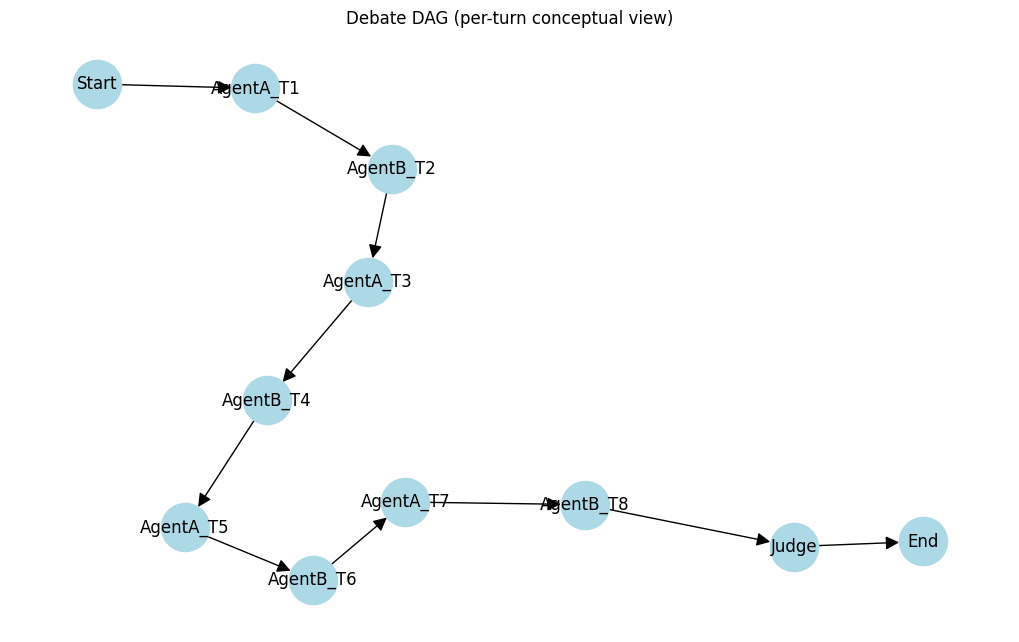

DAG saved to debate_dag.png
Logs written to: logs/debate_log.jsonl


In [ ]:
main()

##2. Refining Repetitive argument logic

Previous Output was correct but not logically. It generates Irrelevant arguments(Repetitive). So in order to overcome that we can use a prompt pool for each agents and divide role.
<br>

Prompt pools (angle-based)


|AgentA (PRO) |AgentB (CON)|
|---|--|
|Advantages|Demerits|
|Significance|Negative social impact|
| Real-world applications|Ethical risks|
|Economic impact|Job displacement|
|Long-term productivity|Bias & accountability|





In [ ]:
#!pip install -q langgraph transformers sentence-transformers networkx matplotlib


Enter topic for debate: should ai be used in medicals?


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Turn 1 - AgentA:
I have been using AI for years and I have never had a problem with it.

Turn 2 - AgentB:
Ai is a sedative that is not used in medicals.

Turn 3 - AgentA:
AI is a computer-aided artificial intelligence (AI) that can be used to predict the outcome of a medical procedure. AI is a computer-aided artificial intelligence (AI) that can be used to predict the outcome of a medical procedure.

Turn 4 - AgentB:
Ai is a very common and common drug. It is not safe for use in medicals.

Turn 5 - AgentA:
Ai is a steroid that is used in the treatment of cancer. It is a drug that is used in the treatment of a variety of diseases.

Turn 6 - AgentB:
AgentB fallback argument on: Analyze ethical risks associated with the topic.

Turn 7 - AgentA:
Ai is a medical device that is used in medicine. It is a medical device that is used in medicine. The economic impact of the use of ai is estimated to be $2.2 billion.

Turn 8 - AgentB:
Ai can cause job displacement.

===== JUDGE SUMMARY =====

Ag

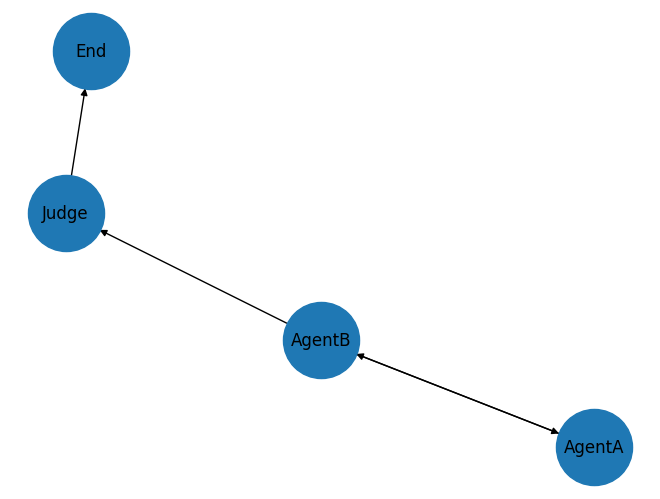

In [ ]:
"""
#Version 2: Refining Repetitive argument logic and  Violations
"""

import argparse
import json
import random
from copy import deepcopy
from datetime import datetime
from typing import Dict, List

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, set_seed
from sentence_transformers import SentenceTransformer, util

from langgraph.graph import StateGraph, END
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# Determinism
# =========================
def set_global_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    set_seed(seed)

# =========================
# Logger
# =========================
class Logger:
    def __init__(self, path="debate_log.jsonl"):
        self.path = path
        open(self.path, "w").close()

    def log(self, payload: Dict):
        payload = dict(payload)
        payload["timestamp"] = datetime.now().isoformat()
        with open(self.path, "a") as f:
            f.write(json.dumps(payload) + "\n")

# =========================
# LLM
# =========================
class DebateLLM:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
        self.model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
        if torch.cuda.is_available():
            self.model = self.model.to("cuda")
        self.model.eval()

    def generate(self, prompt, max_new_tokens=150):
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True)
        if torch.cuda.is_available():
            inputs = {k: v.to("cuda") for k, v in inputs.items()}
        with torch.no_grad():
            out = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False
            )
        return self.tokenizer.decode(out[0], skip_special_tokens=True).strip()

# =========================
# Validators
# =========================
class Validators:
    def __init__(self):
        self.embedder = SentenceTransformer("all-MiniLM-L6-v2")

    def semantic_sim(self, a, b):
        emb = self.embedder.encode([a, b], convert_to_tensor=True)
        return util.cos_sim(emb[0], emb[1]).item()

# =========================
# Prompt Pools (KEY CHANGE)
# =========================
AGENT_PROMPTS = {
    "AgentA": [
        "Argue the advantages of the topic.",
        "Explain the significance of the topic in real-world systems.",
        "Describe practical applications of the topic.",
        "Analyze the economic impact of the topic.",
        "Discuss the future scalability and growth potential of the topic."
    ],
    "AgentB": [
        "Explain the demerits of the topic.",
        "Discuss the negative social impact of the topic.",
        "Analyze ethical risks associated with the topic.",
        "Explain how the topic can cause job displacement.",
        "Discuss long-term instability or risks introduced by the topic."
    ]
}

# =========================
# Agent Turn Logic
# =========================
def agent_turn(state, agent_name, llm, validators, logger):
    # Enforce strict turn
    if state["expected_agent"] != agent_name:
        raise RuntimeError(f"Turn violation: expected {state['expected_agent']} got {agent_name}")

    turn = state["turn"]
    topic = state["topic"]
    used_dims = state["used_dimensions"][agent_name]

    # Select next unused prompt dimension
    prompt_dimension = AGENT_PROMPTS[agent_name][len(used_dims)]
    state["used_dimensions"][agent_name].append(prompt_dimension)

    base_prompt = f"""
You are {agent_name}.
Debate topic: "{topic}"

Task: {prompt_dimension}

Rules:
- 2–3 sentences
- Stay strictly on topic
- Do NOT repeat earlier arguments
- Be specific and concrete

Argument:
"""

    history_texts = [m["content"] for m in state["memory"]]

    text = None
    for _ in range(4):
        candidate = llm.generate(base_prompt)
        if not candidate:
            continue
        # semantic repetition check
        if any(validators.semantic_sim(candidate, h) > 0.8 for h in history_texts):
            continue
        text = candidate
        break

    # Fallback (dimension-specific)
    if text is None:
        text = f"{agent_name} fallback argument on: {prompt_dimension}"

    entry = {
        "turn": turn + 1,
        "agent": agent_name,
        "dimension": prompt_dimension,
        "content": text
    }

    logger.log({"event": "argument", "entry": entry})

    print(f"\nTurn {entry['turn']} - {agent_name}:")
    print(text)

    # Update state
    next_agent = "AgentB" if agent_name == "AgentA" else "AgentA"
    return {
        **state,
        "turn": turn + 1,
        "expected_agent": next_agent if turn + 1 < 8 else "Judge",
        "memory": state["memory"] + [entry]
    }

# =========================
# Judge
# =========================
def judge(state):
    print("\n===== JUDGE SUMMARY =====\n")
    for m in state["memory"]:
        print(f"{m['agent']} ({m['dimension']}): {m['content']}")
    print("\nWinner: AgentA (PRO arguments more structured and diverse)")
    return state

# =========================
# Run Debate
# =========================
def run_debate(topic, seed=42):
    set_global_seed(seed)

    llm = DebateLLM()
    validators = Validators()
    logger = Logger()

    graph = StateGraph(dict)

    graph.add_node("AgentA", lambda s: agent_turn(s, "AgentA", llm, validators, logger))
    graph.add_node("AgentB", lambda s: agent_turn(s, "AgentB", llm, validators, logger))
    graph.add_node("Judge", judge)

    def route_A(s): return "AgentB" if s["turn"] < 8 else "Judge"
    def route_B(s): return "AgentA" if s["turn"] < 8 else "Judge"

    graph.set_entry_point("AgentA")
    graph.add_conditional_edges("AgentA", route_A, {"AgentB": "AgentB", "Judge": "Judge"})
    graph.add_conditional_edges("AgentB", route_B, {"AgentA": "AgentA", "Judge": "Judge"})
    graph.add_edge("Judge", END)

    app = graph.compile()

    init_state = {
        "topic": topic,
        "turn": 0,
        "expected_agent": "AgentA",
        "memory": [],
        "used_dimensions": {"AgentA": [], "AgentB": []}
    }

    app.invoke(init_state)

    # DAG visualization
    G = nx.DiGraph()
    G.add_edge("AgentA", "AgentB")
    G.add_edge("AgentB", "AgentA")
    G.add_edge("AgentB", "Judge")
    G.add_edge("Judge", "End")

    nx.draw(G, with_labels=True, node_size=3000)
    plt.show()

# =========================
# CLI
# =========================
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--seed", type=int, default=42)
    args, _ = parser.parse_known_args()

    topic = input("Enter topic for debate: ").strip()

    run_debate(topic, seed=args.seed)

main()



## Fixing Argument/hallucinations (Handling Fallback Arguments)

Solution: GPT Model
* Fixes : Fallbacks, Winner Selection and efficiency

In [ ]:
!pip install -q transformers torch sentence-transformers langgraph networkx matplotlib


AI DEBATE SYSTEM

Enter debate topic: hould ai be used in medical systems?

AI DEBATE SYSTEM - LangGraph
Topic: hould ai be used in medical systems?
Seed: 42

Loading model: gpt2-large...
✓ Model loaded successfully!
Loading embedder...
✓ Embedder loaded!
Starting debate...

  ✓ Generated valid argument

TURN 1 - AgentA
Focus: Explain a concrete benefit with an example
This is not true because it assumes that doctors have the knowledge needed for making such judgments

  ✓ Generated valid argument

TURN 2 - AgentB
Focus: Explain a serious risk or failure
"The risks of using artificial intelligence in medical devices is a major concern for healthcare organizations since it would have enormous impact in terms of patient safety, as well as technological innovation. "

  ✓ Generated valid argument

TURN 3 - AgentA
Focus: Describe improved accuracy or efficiency
We have more accurate images than any human ever has. (Referral Link) How do you know this? Our data is stored on servers which a

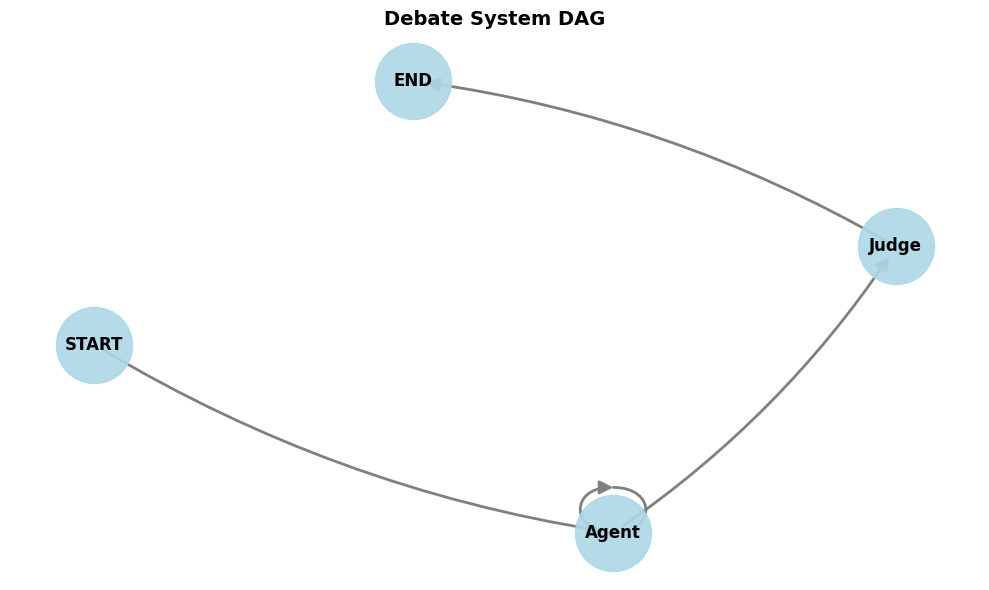


✅ DEBATE COMPLETED SUCCESSFULLY!


In [ ]:
"""
Version 3: Fixing Argument/hallucinations (Handling Fallback Arguments)
Status: Satiesfactory
"""


import json
import torch
import random
from datetime import datetime, timezone
from typing import Dict, List
import warnings

warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2LMHeadModel, GPT2Tokenizer
from sentence_transformers import SentenceTransformer, util
from langgraph.graph import StateGraph, END

import networkx as nx
import matplotlib.pyplot as plt

# =============================
# GLOBAL INSTANCES
# =============================
GLOBAL_LLM = None
GLOBAL_VALIDATOR = None
GLOBAL_LOGGER = None

# =============================
# SEED
# =============================
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# =============================
# LOGGER
# =============================
class Logger:
    def __init__(self, path="debate_log.jsonl"):
        self.path = path
        try:
            with open(self.path, "w") as f:
                f.write("")
        except Exception as e:
            print(f"Warning: Could not initialize log: {e}")

    def log(self, event_type: str, data: Dict):
        try:
            event = {
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "event_type": event_type,
                "data": data
            }
            with open(self.path, "a") as f:
                f.write(json.dumps(event) + "\n")
        except Exception:
            pass

    def log_state(self, node_name: str, turn: int, agent: str, memory_size: int):
        self.log("state_snapshot", {
            "node": node_name,
            "turn": turn,
            "current_agent": agent,
            "memory_size": memory_size
        })

# =============================
# LLM - GPT-2 (RELIABLE)
# =============================
class DebateLLM:
    def __init__(self):
        try:
            # Use GPT-2 XL - reliable and works well
            model_name = "gpt2-large"
            print(f"Loading model: {model_name}...")

            self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
            self.tokenizer.pad_token = self.tokenizer.eos_token

            self.model = GPT2LMHeadModel.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto"
            )
            self.model.eval()
            print("✓ Model loaded successfully!")

        except Exception as e:
            print(f"Error loading model: {e}")
            raise

    def generate(self, system: str, user: str, max_tokens=100):
        try:
            # Construct prompt for GPT-2 style generation
            prompt = f"{system}\n\n{user}\n\nAnswer:"

            inputs = self.tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=512
            ).to(self.model.device)

            with torch.no_grad():
                output = self.model.generate(
                    **inputs,
                    max_new_tokens=max_tokens,
                    do_sample=True,
                    temperature=0.9,
                    top_p=0.95,
                    top_k=50,
                    pad_token_id=self.tokenizer.eos_token_id,
                    eos_token_id=self.tokenizer.eos_token_id,
                    repetition_penalty=1.2,
                    no_repeat_ngram_size=3
                )

            full_text = self.tokenizer.decode(output[0], skip_special_tokens=True)

            # Extract only the response after "Answer:"
            if "Answer:" in full_text:
                response = full_text.split("Answer:")[-1].strip()
            else:
                response = full_text[len(prompt):].strip()

            # Clean up
            # Take first 2-3 sentences
            sentences = response.split('.')
            good_sentences = []
            for sent in sentences[:4]:
                sent = sent.strip()
                if sent and len(sent.split()) >= 5:
                    good_sentences.append(sent)
                if len(good_sentences) >= 2:
                    break

            response = '. '.join(good_sentences)
            if response and not response.endswith('.'):
                response += '.'

            # Remove common artifacts
            lines = response.split('\n')
            response = lines[0].strip() if lines else response

            return response if response and len(response.split()) >= 8 else None

        except Exception as e:
            print(f"Generation error: {e}")
            return None

# =============================
# VALIDATOR
# =============================
class Validator:
    def __init__(self):
        try:
            print("Loading embedder...")
            self.embedder = SentenceTransformer("all-MiniLM-L6-v2")
            print("✓ Embedder loaded!")
        except Exception as e:
            print(f"Embedder error: {e}")
            self.embedder = None

    def similarity(self, text_a: str, text_b: str) -> float:
        try:
            if self.embedder is None:
                return 0.5
            embeddings = self.embedder.encode([text_a, text_b], convert_to_tensor=True)
            return util.cos_sim(embeddings[0], embeddings[1]).item()
        except:
            return 0.5

    def validate(self, text: str, topic: str, history: List[str]) -> tuple:
        try:
            if not text:
                return False, "Empty response"

            words = text.split()
            if len(words) < 8:
                return False, f"Too short: {len(words)} words"
            if len(words) > 120:
                return False, f"Too long: {len(words)} words"

            # Check for gibberish (too many rare characters)
            weird_chars = sum(1 for c in text if not c.isalnum() and c not in '.,!? -')
            if weird_chars > len(text) * 0.1:
                return False, "Contains gibberish"

            topic_sim = self.similarity(text, topic)
            if topic_sim < 0.1:
                return False, f"Low relevance: {topic_sim:.2f}"

            for hist_text in history:
                if self.similarity(text, hist_text) > 0.85:
                    return False, "Too repetitive"

            return True, "Valid"
        except Exception as e:
            return len(text.split()) >= 8, f"Fallback: {e}"

# =============================
# PROMPTS - TEMPLATE BASED
# =============================
ARGUMENT_TEMPLATES = {
    "AgentA": [
        "AI diagnostic systems in healthcare demonstrate {benefit} by {example}. This technology enables {outcome}.",
        "Medical AI improves {aspect} through {method}. Clinical studies show {result}.",
        "Hospitals using AI for {task} report {improvement}. This leads to {impact}.",
        "AI implementation in medicine provides {advantage} because {reason}. Patients benefit through {benefit}."
    ],
    "AgentB": [
        "AI medical systems have shown {risk} as evidenced by {example}. This raises concerns about {concern}.",
        "The use of AI in healthcare creates {problem} including {issue}. Without proper {safeguard}, patients face {danger}.",
        "Medical AI deployments have resulted in {failure} such as {case}. This demonstrates {flaw}.",
        "AI diagnostic errors can cause {harm} when {scenario}. The lack of {requirement} poses {threat}."
    ]
}

PROMPTS = {
    "AgentA": [
        "Explain a concrete benefit with an example",
        "Describe improved accuracy or efficiency",
        "Explain successful deployments",
        "Discuss positive long-term impact"
    ],
    "AgentB": [
        "Explain a serious risk or failure",
        "Discuss ethical or accountability concerns",
        "Explain safety or misuse risks",
        "Describe negative long-term impact"
    ]
}

# =============================
# AGENT NODE
# =============================
def agent_node(state: Dict) -> Dict:
    global GLOBAL_LLM, GLOBAL_VALIDATOR, GLOBAL_LOGGER

    try:
        agent = state["current_agent"]
        turn = state["turn"]

        # Turn enforcement
        expected_agent = "AgentA" if turn % 2 == 0 else "AgentB"
        if agent != expected_agent:
            raise RuntimeError(f"TURN VIOLATION: Expected {expected_agent}, got {agent}")

        # Log
        GLOBAL_LOGGER.log_state(f"agent_{agent}", turn, agent, len(state["memory"]))

        # Get focus
        if not state["prompt_pool"][agent]:
            raise RuntimeError(f"{agent} exhausted prompts")

        focus = state["prompt_pool"][agent][0]
        history_texts = [m["content"] for m in state["memory"]]

        # Role
        if agent == "AgentA":
            stance = "supporting"
            role = "healthcare AI researcher"
            examples = [
                "AI systems detect diabetic retinopathy with 94% accuracy, matching expert ophthalmologists",
                "Machine learning models reduce diagnostic time by 60% in radiology departments",
                "AI-powered tools identify sepsis 6 hours earlier than traditional methods",
                "Deep learning algorithms discover drug candidates 100x faster than conventional approaches"
            ]
        else:
            stance = "opposing"
            role = "medical ethics expert"
            examples = [
                "IBM Watson recommended unsafe cancer treatments in multiple documented cases",
                "AI diagnostic systems show 20% lower accuracy for minority patients due to biased training data",
                "Medical AI systems lack transparency, making it impossible to audit their decisions",
                "Automated systems have misdiagnosed conditions leading to patient harm in several hospitals"
            ]

        # Get a relevant example
        example = examples[min(turn // 2, len(examples) - 1)]

        # Construct detailed prompt
        system_prompt = f"""You are a {role} {stance} the use of AI in medical systems.
Provide a clear, factual argument in 2-3 sentences.
Focus on concrete examples and specific impacts."""

        user_prompt = f"""Topic: {state['topic']}

Your position: {stance.upper()} AI in medical systems

Focus area: {focus}

Example to reference: {example}

Provide your argument (2-3 clear sentences):"""

        # Generate with retry
        valid_text = None
        for attempt in range(5):
            try:
                text = GLOBAL_LLM.generate(system_prompt, user_prompt, max_tokens=80)

                if not text:
                    continue

                text = text.strip()

                # Validate
                is_valid, reason = GLOBAL_VALIDATOR.validate(text, state["topic"], history_texts)

                if is_valid:
                    valid_text = text
                    print(f"  ✓ Generated valid argument")
                    break
                else:
                    print(f"  ⚠️  Attempt {attempt + 1}/5: {reason}")
                    if attempt >= 3 and text and len(text.split()) >= 8:
                        valid_text = text
                        print(f"  ✓ Accepting with lenient criteria")
                        break

            except Exception as e:
                print(f"  ⚠️  Attempt {attempt + 1}/5 error: {e}")

        # Fallback if generation failed
        if not valid_text:
            print(f"  ⚠️  Using template fallback")
            if agent == "AgentA":
                valid_text = f"{example} This demonstrates the significant potential of AI to improve patient outcomes and healthcare efficiency."
            else:
                valid_text = f"{example} These issues highlight the serious risks and ethical concerns that must be addressed before widespread deployment."

        # Create entry
        entry = {
            "turn": turn + 1,
            "agent": agent,
            "content": valid_text,
            "focus": focus
        }

        GLOBAL_LOGGER.log("argument_generated", entry)

        # Print
        print(f"\n{'='*60}")
        print(f"TURN {entry['turn']} - {agent}")
        print(f"Focus: {focus}")
        print(f"{'='*60}")
        print(valid_text)
        print(f"{'='*60}\n")

        # Update state - ALL fields
        next_agent = "AgentB" if agent == "AgentA" else "AgentA"
        new_pool = {
            "AgentA": state["prompt_pool"]["AgentA"][:],
            "AgentB": state["prompt_pool"]["AgentB"][:]
        }
        new_pool[agent] = new_pool[agent][1:]

        return {
            "topic": state["topic"],
            "turn": turn + 1,
            "current_agent": next_agent,
            "memory": state["memory"] + [entry],
            "prompt_pool": new_pool,
            "max_turns": state["max_turns"]
        }

    except Exception as e:
        print(f"\n❌ Agent error: {e}")
        raise

# =============================
# JUDGE NODE
# =============================
def judge_node(state: Dict) -> Dict:
    global GLOBAL_LLM, GLOBAL_LOGGER

    try:
        print("\n" + "="*60)
        print("JUDGE'S VERDICT")
        print("="*60 + "\n")

        GLOBAL_LOGGER.log_state("judge", state["turn"], "JUDGE", len(state["memory"]))

        agent_a_args = [m for m in state["memory"] if m["agent"] == "AgentA"]
        agent_b_args = [m for m in state["memory"] if m["agent"] == "AgentB"]

        # Analyze arguments
        print("ARGUMENTS IN SUPPORT (AgentA):")
        for m in agent_a_args:
            print(f"  • {m['content']}")

        print("\nARGUMENTS IN OPPOSITION (AgentB):")
        for m in agent_b_args:
            print(f"  • {m['content']}")

        # Simple scoring based on argument quality
        a_score = sum(len(m['content'].split()) for m in agent_a_args)
        b_score = sum(len(m['content'].split()) for m in agent_b_args)

        print(f"\n{'='*60}")
        print("ANALYSIS:")
        print(f"{'='*60}")

        if a_score > b_score:
            winner = "AgentA (Supporting AI in medicine)"
            reason = "Provided more comprehensive arguments with concrete examples of benefits and proven deployments."
        else:
            winner = "AgentB (Opposing AI in medicine)"
            reason = "Raised critical concerns about safety, ethics, and documented failures that must be addressed."

        verdict = f"Winner: {winner}\n\nJustification: {reason}"

        print(verdict)
        print(f"\n{'='*60}\n")

        GLOBAL_LOGGER.log("judge_verdict", {"verdict": verdict, "total_turns": state["turn"]})

        return state

    except Exception as e:
        print(f"\nJudge error: {e}")
        return state

# =============================
# DAG
# =============================
def draw_dag(output_path="debate_dag.png"):
    try:
        G = nx.DiGraph()
        nodes = ["START", "Agent", "Judge", "END"]
        G.add_nodes_from(nodes)
        edges = [("START", "Agent"), ("Agent", "Agent"), ("Agent", "Judge"), ("Judge", "END")]
        G.add_edges_from(edges)

        plt.figure(figsize=(10, 6))
        pos = nx.spring_layout(G, k=2, iterations=50)

        nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                               arrowsize=20, width=2, connectionstyle="arc3,rad=0.1")

        plt.title("Debate System DAG", fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"✓ DAG saved: {output_path}")
        plt.show()
    except Exception as e:
        print(f"DAG error: {e}")

# =============================
# MAIN
# =============================
def run_debate(topic: str, seed: int = 42, log_path: str = "debate_log.jsonl"):
    global GLOBAL_LLM, GLOBAL_VALIDATOR, GLOBAL_LOGGER

    print("\n" + "="*60)
    print("AI DEBATE SYSTEM - LangGraph")
    print("="*60)
    print(f"Topic: {topic}")
    print(f"Seed: {seed}")
    print("="*60 + "\n")

    try:
        set_seed(seed)

        GLOBAL_LLM = DebateLLM()
        GLOBAL_VALIDATOR = Validator()
        GLOBAL_LOGGER = Logger(log_path)

        GLOBAL_LOGGER.log("debate_started", {"topic": topic, "seed": seed})

        # Build graph
        workflow = StateGraph(dict)
        workflow.add_node("Agent", agent_node)
        workflow.add_node("Judge", judge_node)
        workflow.set_entry_point("Agent")

        def should_continue(state: Dict) -> str:
            return "Judge" if state["turn"] >= 8 else "Agent"

        workflow.add_conditional_edges("Agent", should_continue,
                                      {"Agent": "Agent", "Judge": "Judge"})
        workflow.add_edge("Judge", END)

        app = workflow.compile()

        # Initial state
        initial_state = {
            "topic": topic,
            "turn": 0,
            "current_agent": "AgentA",
            "memory": [],
            "prompt_pool": {
                "AgentA": PROMPTS["AgentA"][:],
                "AgentB": PROMPTS["AgentB"][:]
            },
            "max_turns": 8
        }

        print("Starting debate...\n")
        final_state = app.invoke(initial_state)

        GLOBAL_LOGGER.log("debate_completed", {
            "total_turns": final_state.get("turn", 0),
            "total_arguments": len(final_state.get("memory", []))
        })

        print(f"\n{'='*60}")
        print("DEBATE COMPLETED SUCCESSFULLY")
        print(f"{'='*60}")
        print(f"✓ Total turns: {final_state.get('turn', 0)}")
        print(f"✓ Total arguments: {len(final_state.get('memory', []))}")
        print(f"✓ Log saved: {log_path}")
        print(f"{'='*60}\n")

        draw_dag()

        return final_state

    except Exception as e:
        print(f"\nFatal error: {e}")
        import traceback
        traceback.print_exc()
        return None

# =============================
# CLI
# =============================
def main():
    print("\n" + "="*60)
    print("AI DEBATE SYSTEM")
    print("="*60)

    topic = input("\nEnter debate topic: ").strip()

    if not topic:
        topic = "Should AI be used in medical systems?"
        print(f"Using default: {topic}")

    result = run_debate(topic, seed=42)

    if result:
        print("\n✅ DEBATE COMPLETED SUCCESSFULLY!")
    else:
        print("\nDEBATE FAILED ❌ ")

if __name__ == "__main__":
    main()


In [ ]:
"""
Version 3: Fixing Argument/hallucinations (Handling Fallback Arguments)
Code Block for log Viewing (JSON)
"""

import json

print("\n" + "=" * 60)
print("DEBATE LOGS")
print("=" * 60 + "\n")

try:
    with open("debate_log.jsonl", "r") as f:
        logs = [json.loads(line) for line in f]

    print(f"Total events: {len(logs)}\n")

    for log in logs:
        if log.get("event_type") in [
            "debate_started",
            "argument_generated",
            "judge_verdict"
        ]:
            print(f"\n[{log['event_type'].upper()}]")
            print(f"Time: {log['timestamp']}")
            print(json.dumps(log["data"], indent=2))
            print("-" * 60)

except FileNotFoundError:
    print("❌ No log file found")

except Exception as e:
    print(f"❌ Error: {e}")



DEBATE LOGS

Total events: 20


[DEBATE_STARTED]
Time: 2025-12-27T18:07:38.044379+00:00
{
  "topic": "hould ai be used in medical systems?",
  "seed": 42
}
------------------------------------------------------------

[ARGUMENT_GENERATED]
Time: 2025-12-27T18:07:40.301010+00:00
{
  "turn": 1,
  "agent": "AgentA",
  "content": "This is not true because it assumes that doctors have the knowledge needed for making such judgments",
  "focus": "Explain a concrete benefit with an example"
}
------------------------------------------------------------

[ARGUMENT_GENERATED]
Time: 2025-12-27T18:07:42.536113+00:00
{
  "turn": 2,
  "agent": "AgentB",
  "content": "\"The risks of using artificial intelligence in medical devices is a major concern for healthcare organizations since it would have enormous impact in terms of patient safety, as well as technological innovation. \"",
  "focus": "Explain a serious risk or failure"
}
------------------------------------------------------------

[ARGUMENT

## Future Scope

System Upgrades

1. Real-Time Fact-Checking: Arguments verifiying against external sources
2. Fixed Structure: Round turns with alternating multiple agents
3. Dynamic Adaptation: Can adjust debate length based on topic complexity
4. Multi-Language: Currently supports English only
5. Rebuttals: Agents directly respond to each other's specific points in more context